# Taller 3 -- MLops EIA

- Juan Jairo Araque Giraldo

Se aplicará la metodología ASUM – DM para todo el desarrollo del taller 3, se creará un entorno virtual propio para la prueba, se crea el archivo requirements.

> **Nota de autoría:** las secciones de tracking con MLflow, búsqueda de hiperparámetros con Optuna para los 5 modelos, evaluación final y despliegue (pipeline + FastAPI + EC2) fueron completadas por mí, Juan Jairo, con asistencia de Claude (Anthropic) para acelerar la redacción del código y las explicaciones.

# Entendimiento del negocio

El set de datos presenta los salarios de los trabajos relacionados a ciencia de datos (Kaggle: *Data Science Salaries 2023*).

**Objetivo de negocio:** apoyar a un área de Recursos Humanos / adquisición de talento a definir **bandas salariales competitivas** para roles de ciencia de datos. Conocer el salario esperado según el perfil (nivel de experiencia, tipo de empleo, título del cargo, país de la empresa, modalidad remota, tamaño de la empresa, año) permite: (1) construir ofertas alineadas al mercado para reducir la fuga de candidatos por ofertas bajas y el sobrecosto por ofertas infladas, y (2) dar a los candidatos un *benchmark* realista de lo que pueden esperar.

**Objetivo analítico:** entrenar un **modelo de regresión** que prediga `salario_en_usd` a partir de las variables de perfil disponibles. El criterio de éxito es minimizar el error de predicción en dólares (RMSE/MAE bajos) manteniendo una capacidad explicativa razonable (R² aceptable), de forma que la estimación sea suficientemente confiable para usarse como referencia en la negociación salarial.

# Requerimiento de datos

- Modelo para predecir cuánto podría ser el salario que  teniendo en cuenta la información disponible. 


# Análisis exploratorio

Revisamos los datos para la exploración inicial

In [1]:
#Importamos librerías
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Se configura después de importar seaborn para que no lo sobreescriba
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']

#Leemos el set de datos desde el csv descargado de kaggle
data_csv = pd.read_csv('ds_salaries.csv')
data_csv.tail()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
3750,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
3751,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
3752,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
3753,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L
3754,2021,SE,FT,Data Science Manager,7000000,INR,94665,IN,50,IN,L


In [2]:
#Atributo del dataframe para copiar los nombres de las columnas para su renombre en español para facilidad del negocio
data_csv.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [3]:
#Se crea una copia para evitar dañar los daños crudos
data = data_csv.copy()
#No se usan tildes para evitar algún error en el dataframe
renombrar = {'work_year': 'año_trabajo', 'experience_level': 'nivel_experiencia', 'employment_type': 'tipo_empleo', 'job_title': 'titulo_trabajo',
       'salary': 'salario', 'salary_currency': 'moneda_salario', 'salary_in_usd': 'salario_en_usd', 'employee_residence': 'residencia_empleado',
       'remote_ratio': 'ratio_remoto', 'company_location': 'ubicacion_empresa', 'company_size': 'tamaño_empresa'}
data = data.rename(columns=renombrar)
data.head()

,año_trabajo,nivel_experiencia,tipo_empleo,titulo_trabajo,salario,moneda_salario,salario_en_usd,residencia_empleado,ratio_remoto,ubicacion_empresa,tamaño_empresa
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [4]:
# Para validar datos nulos y tipo de datos de las columnas
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   año_trabajo          3755 non-null   int64 
 1   nivel_experiencia    3755 non-null   object
 2   tipo_empleo          3755 non-null   object
 3   titulo_trabajo       3755 non-null   object
 4   salario              3755 non-null   int64 
 5   moneda_salario       3755 non-null   object
 6   salario_en_usd       3755 non-null   int64 
 7   residencia_empleado  3755 non-null   object
 8   ratio_remoto         3755 non-null   int64 
 9   ubicacion_empresa    3755 non-null   object
 10  tamaño_empresa       3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


In [5]:
#Se valida la cantidad de datos únicos por columna
data.nunique()

año_trabajo               4
nivel_experiencia         4
tipo_empleo               4
titulo_trabajo           93
salario                 815
moneda_salario           20
salario_en_usd         1035
residencia_empleado      78
ratio_remoto              3
ubicacion_empresa        72
tamaño_empresa            3
dtype: int64

In [6]:
data.duplicated().sum()

1171

In [7]:
#Se eliminan duplicados
data = data.drop_duplicates()
#Verificamos los datos estadísticos con describe
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
año_trabajo,2584.0,2022.301084,0.749179,2020.0,2022.0,2022.0,2023.0,2023.0
salario,2584.0,210365.296440,808037.535609,6000.0,90000.0,134630.0,182562.5,30400000.0
salario_en_usd,2584.0,133409.280186,67136.837329,5132.0,84975.0,130000.0,175000.0,450000.0
ratio_remoto,2584.0,50.483746,48.163707,0.0,0.0,50.0,100.0,100.0


Hay variables que posiblemente sean categóricas dado que su información estadística no tiene sentido.

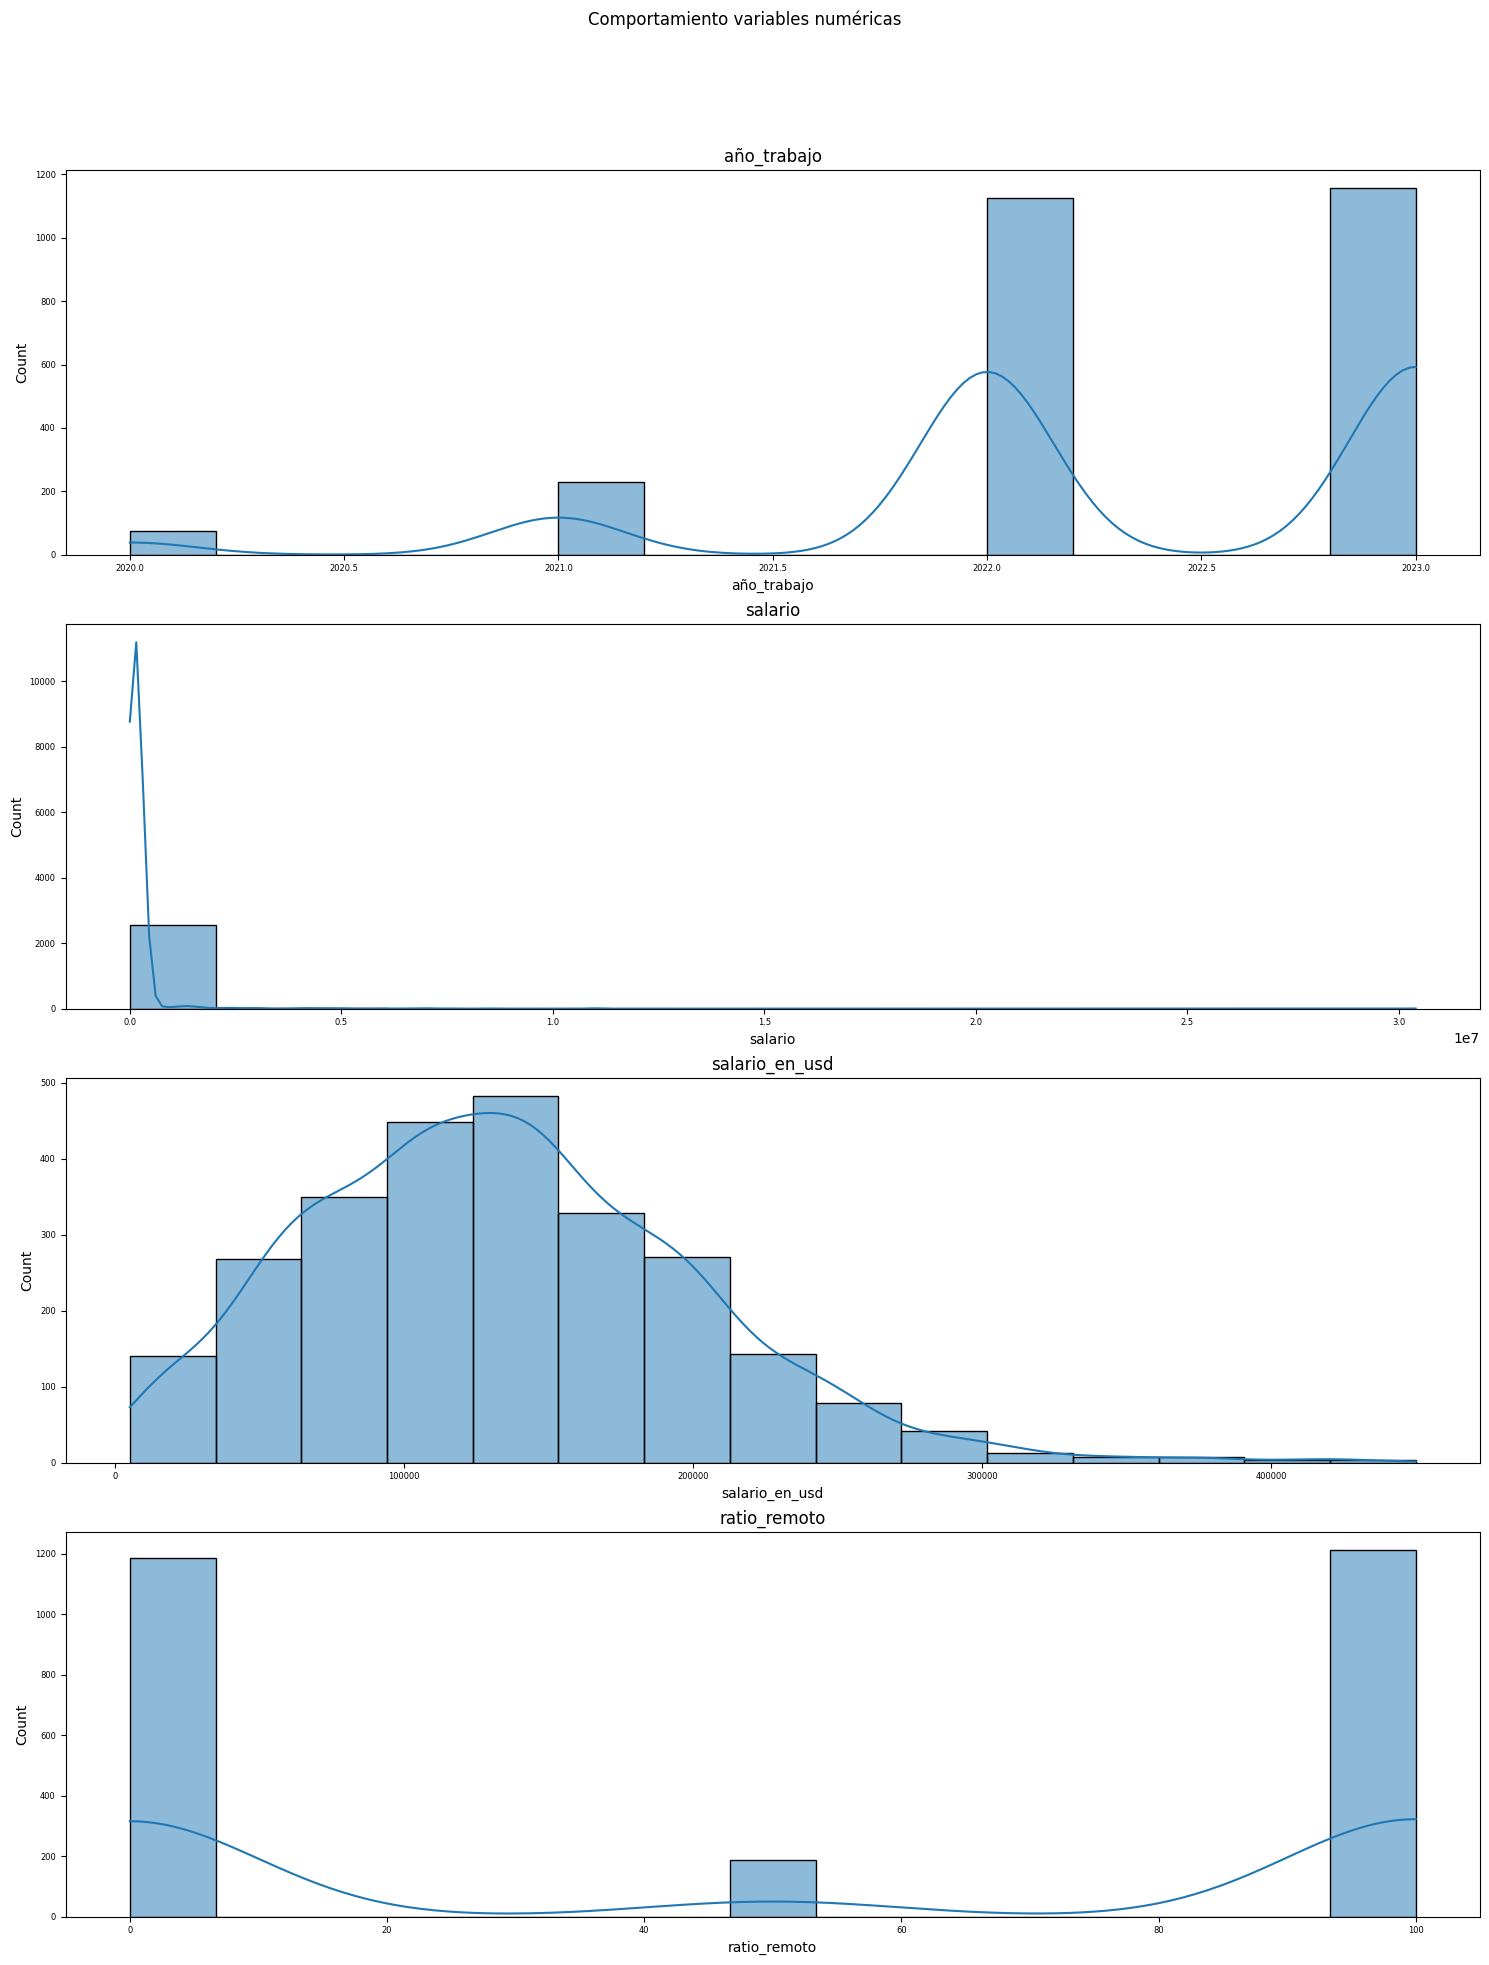

In [8]:
# Gráfico para determinar variables númericas que no tienen sentido y posiblemente sean categóricas 
#Histograma
fig, ax = plt.subplots(4, 1, figsize = (15, 20))
ax = ax.flat
num_col = data.select_dtypes(include = ['int64', 'float64']).columns
for i, col in enumerate(num_col):
    sns.histplot(data = data, x = col, kde = True, ax= ax[i], bins = 15)
    ax[i].set_title(col)
    ax[i].tick_params(labelsize = 6)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle('Comportamiento variables numéricas')
plt.show()

In [9]:
data.columns

Index(['año_trabajo', 'nivel_experiencia', 'tipo_empleo', 'titulo_trabajo',
       'salario', 'moneda_salario', 'salario_en_usd', 'residencia_empleado',
       'ratio_remoto', 'ubicacion_empresa', 'tamaño_empresa'],
      dtype='object')

In [10]:
#Se convierten a variables categóricas
data[['año_trabajo', 'ratio_remoto']] = data[['año_trabajo', 'ratio_remoto']].astype('str')

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2584 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   año_trabajo          2584 non-null   object
 1   nivel_experiencia    2584 non-null   object
 2   tipo_empleo          2584 non-null   object
 3   titulo_trabajo       2584 non-null   object
 4   salario              2584 non-null   int64 
 5   moneda_salario       2584 non-null   object
 6   salario_en_usd       2584 non-null   int64 
 7   residencia_empleado  2584 non-null   object
 8   ratio_remoto         2584 non-null   object
 9   ubicacion_empresa    2584 non-null   object
 10  tamaño_empresa       2584 non-null   object
dtypes: int64(2), object(9)
memory usage: 242.2+ KB


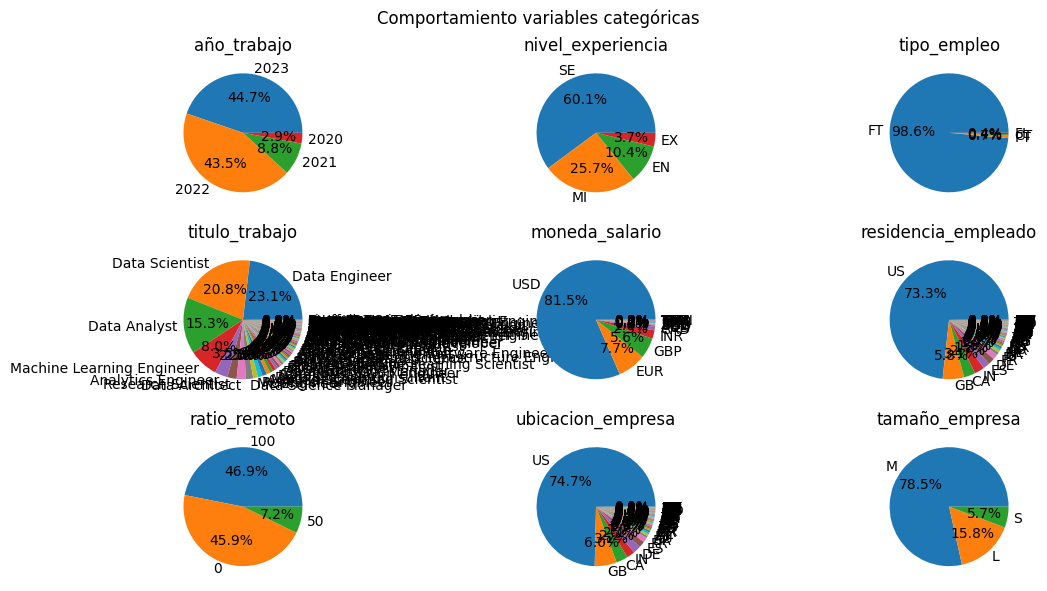

In [12]:
fig, ax = plt.subplots(3, 3, figsize = (10, 6))
ax = ax.flat
cat_col = data.select_dtypes(include = ['object']).columns
for i, col in enumerate(cat_col):
    ax[i].pie(x = data[col].value_counts(), labels= data[col].value_counts().index, autopct = '%0.1f%%')
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle('Comportamiento variables categóricas')
plt.show()

Se eliminan categorías con el fin de reducir las cantidades

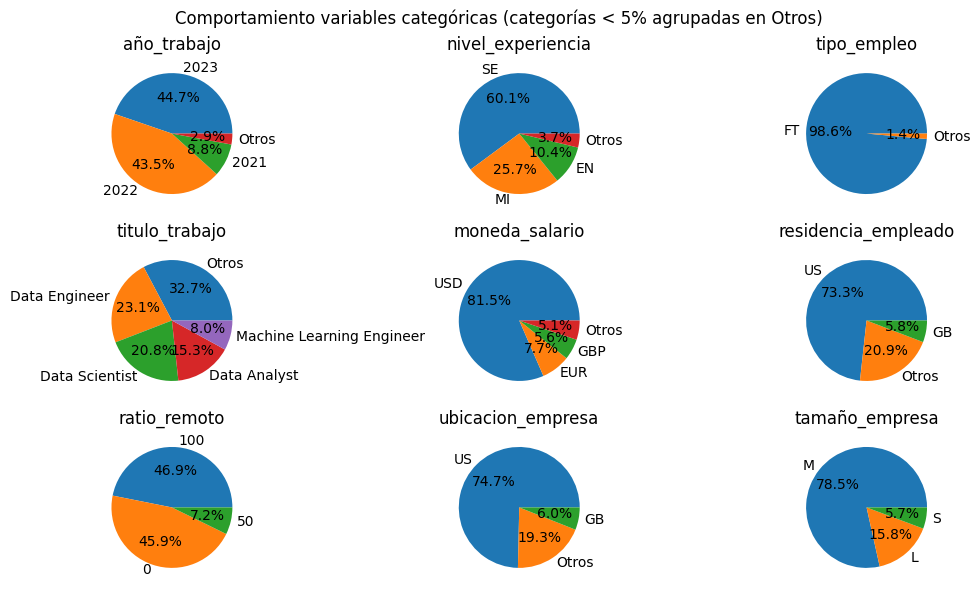

In [13]:
# Categorías con menos del 5% se agrupan en "Otros"
cat_col = data.select_dtypes(include=['object']).columns

for col in cat_col:
    freq = data[col].value_counts(normalize=True)
    categorias_otras = freq[freq < 0.05].index
    data[col] = data[col].apply(lambda x: 'Otros' if x in categorias_otras else x)

# Se vuelven a graficar las variables categóricas con las categorías agrupadas
fig, ax = plt.subplots(3, 3, figsize=(10, 6))
ax = ax.flat
for i, col in enumerate(cat_col):
    ax[i].pie(x=data[col].value_counts(), labels=data[col].value_counts().index, autopct='%0.1f%%')
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.suptitle('Comportamiento variables categóricas (categorías < 5% agrupadas en Otros)')
plt.show()

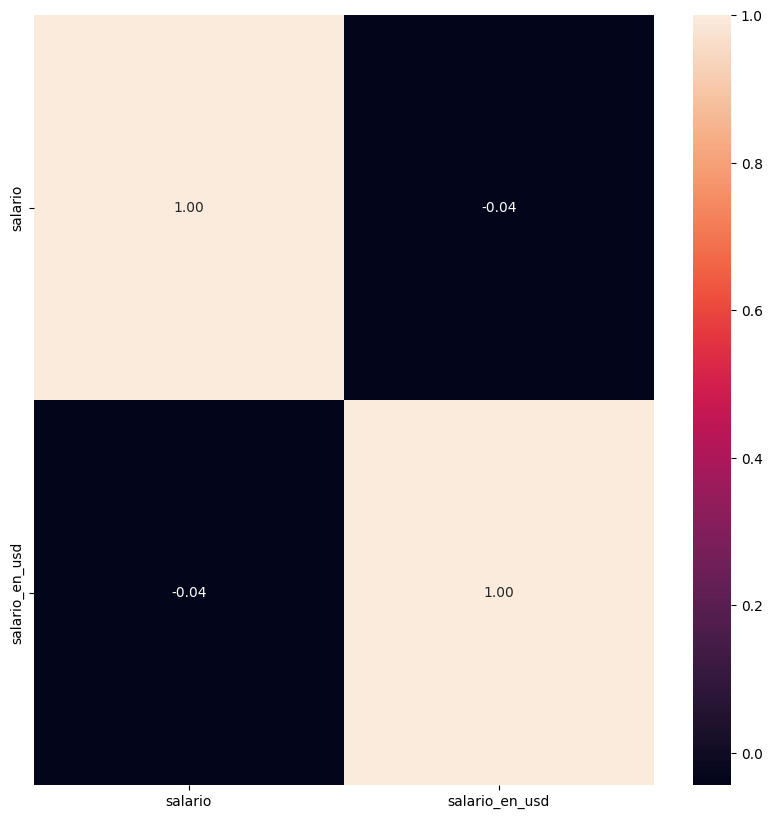

In [14]:
plt.figure(figsize=(10, 10))
sns.heatmap(data = data.corr(numeric_only = True), annot = True,
            fmt = '0.2f')
plt.show()

Las 2 columnas numéricas están altamente correlacionadas por lo que solo se trabajará con una

In [15]:
#Eliminar del df las columnas correlacionadas además es nuestra variable objetivo
data = data.drop(columns = ['salario','moneda_salario'])
data.head()

,año_trabajo,nivel_experiencia,tipo_empleo,titulo_trabajo,salario_en_usd,residencia_empleado,ratio_remoto,ubicacion_empresa,tamaño_empresa
0,2023,SE,FT,Otros,85847,Otros,100,Otros,L
1,2023,MI,Otros,Otros,30000,US,100,US,S
2,2023,MI,Otros,Otros,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,Otros,100,Otros,M
4,2023,SE,FT,Data Scientist,120000,Otros,100,Otros,M


# Preparación de datos

### Selección de variables de entrada y de salida
- **Variable de salida (target):** `salario_en_usd`. Se eligió `salario_en_usd` en lugar de `salario` porque está homogeneizada a una sola moneda (USD), lo que la hace comparable entre países; `salario` y `moneda_salario` se eliminaron por estar fuertemente correlacionadas/redundantes con el target y por mezclar monedas.
- **Variables de entrada:** el resto de columnas de perfil (`año_trabajo`, `nivel_experiencia`, `tipo_empleo`, `titulo_trabajo`, `residencia_empleado`, `ratio_remoto`, `ubicacion_empresa`, `tamaño_empresa`). `año_trabajo` y `ratio_remoto` se trataron como **categóricas** porque sus valores discretos no tienen sentido como magnitudes continuas.
- **Transformación de la variable de salida:** se escala con **MinMaxScaler** (a rango 0–1) para la fase de modelación/comparación; las métricas interpretables en dólares (MAE/MAPE) se calculan re-escalando a la escala original.

### Listado de transformaciones / procesos más usados en esta etapa
A continuación, las técnicas más comunes de *data preparation* (se marca ✅ las aplicadas en este taller):

1. **Limpieza de datos**
   - Manejo de **valores nulos**: eliminación o imputación (media/mediana/moda, KNN, imputación por modelo). *(Aquí no hubo nulos.)*
   - Eliminación de **duplicados** ✅.
   - Tratamiento de **outliers**: recorte (clipping), winsorización o transformaciones.
2. **Codificación de variables categóricas**
   - **One-Hot Encoding** ✅ (usado), Ordinal/Label Encoding, Target/Frequency Encoding.
   - **Agrupación de categorías raras** ✅ (categorías con frecuencia < 5% agrupadas en `Otros`) para reducir dimensionalidad y evitar columnas dispersas.
3. **Escalado / normalización de numéricas**
   - **MinMaxScaler** ✅, StandardScaler, RobustScaler.
4. **Transformaciones del target / numéricas**
   - Log, Box-Cox / Yeo-Johnson para reducir asimetría; **escalado del target** ✅.
5. **Selección de variables (feature selection)**
   - Eliminación por **alta correlación** ✅ (se descartó `salario`), filtros estadísticos, importancia por modelo, RFE.
6. **Ingeniería de características (feature engineering)**
   - Creación de variables derivadas, *binning*, interacciones.
7. **Manejo de desbalance** (en clasificación): SMOTE, submuestreo/sobremuestreo. *(No aplica en regresión.)*
8. **Particionamiento**: división **train/test** ✅ (y validación cruzada en la modelación).

> *(Sección completada con asistencia de Claude.)*

In [16]:
#Se realiza la transformación de las variables numéricas y categoricas para el modelo a escoger
num_col = data.select_dtypes(include = ['int64', 'float64']).columns.to_list()
cat_col = data.select_dtypes(include = ['object']).columns.to_list()
num_transformer = Pipeline(steps = [('scaler', MinMaxScaler())])
cat_transformer = Pipeline(steps = [('encoder', OneHotEncoder())])
preprocessor = ColumnTransformer(transformers = [('num', num_transformer, num_col),
                                                 ('cat', cat_transformer, cat_col)],
                                                 remainder = 'passthrough')
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('scaler', MinMaxScaler())]),
                                 ['salario_en_usd']),
                                ('cat',
                                 Pipeline(steps=[('encoder', OneHotEncoder())]),
                                 ['año_trabajo', 'nivel_experiencia',
                                  'tipo_empleo', 'titulo_trabajo',
                                  'residencia_empleado', 'ratio_remoto',
                                  'ubicacion_empresa', 'tamaño_empresa'])])

In [17]:
data_pre = preprocessor.fit_transform(data)
cod_cat = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_col)
labels = np.concatenate([num_col, cod_cat])
data_pro = pd.DataFrame(data_pre, columns = labels)
data_pro.head(10)

,salario_en_usd,año_trabajo_2021,año_trabajo_2022,año_trabajo_2023,año_trabajo_Otros,nivel_experiencia_EN,nivel_experiencia_MI,nivel_experiencia_Otros,nivel_experiencia_SE,tipo_empleo_FT,...,residencia_empleado_US,ratio_remoto_0,ratio_remoto_100,ratio_remoto_50,ubicacion_empresa_GB,ubicacion_empresa_Otros,ubicacion_empresa_US,tamaño_empresa_L,tamaño_empresa_M,tamaño_empresa_S
0,0.181436,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0.055900,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.045784,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.381839,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.258207,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
5,0.487938,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
6,0.294173,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
7,0.480745,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
8,0.305412,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
9,0.319124,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [18]:
X = data_pro.drop('salario_en_usd', axis = 1)
y = data_pro[['salario_en_usd']]

In [19]:
np.random.seed(31)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7, random_state = 15)
print(f'El tamaño del conjunto de entrenamiento es: {X_train.shape} {y_train.shape}\nEl tamaño del conjunto de validación es {X_test.shape} {y_test.shape}')

El tamaño del conjunto de entrenamiento es: (1808, 27) (1808, 1)
El tamaño del conjunto de validación es (776, 27) (776, 1)


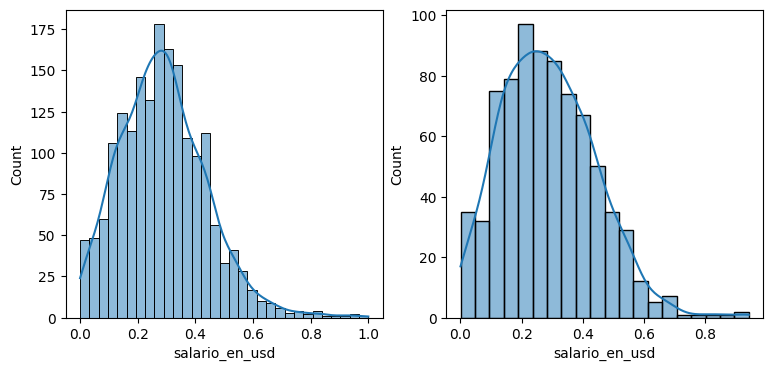

In [20]:
fig, ax = plt.subplots(1, 2, figsize = (9, 4))
sns.histplot(data = y_train, x = 'salario_en_usd', kde = True, ax = ax[0])
sns.histplot(data = y_test, x = 'salario_en_usd', kde = True, ax = ax[1])
plt.show()

# Realizamos el modelo

## Tracking de experimentos con MLflow

Antes de modelar configuramos **MLflow** para registrar todos los experimentos y ejecuciones (punto 4 del taller). Se usa un *tracking store* local en la carpeta `./mlruns`, de modo que cualquiera puede revisar los runs ejecutando `mlflow ui` en la terminal. PyCaret se integra automáticamente con MLflow (`log_experiment=True`), y además se loguea de forma explícita el modelo Ridge para mostrar el registro manual de parámetros, métricas y artefactos.

In [21]:
# Configuración de MLflow para el tracking de experimentos (completado con asistencia de Claude)
import os
# MLflow 3.x marca el almacenamiento en carpeta como "maintenance mode"; con esta
# variable habilitamos el tracking local en ./mlruns (sin necesidad de servidor/DB).
os.environ['MLFLOW_ALLOW_FILE_STORE'] = 'true'
import mlflow

# Se define el nombre del experimento que agrupará todas las ejecuciones
NOMBRE_EXPERIMENTO = 'taller3_salarios_ds'

# Tracking store local en la carpeta ./mlruns (se puede visualizar con: mlflow ui)
mlflow.set_tracking_uri('file:./mlruns')
mlflow.set_experiment(NOMBRE_EXPERIMENTO)
print(f'MLflow listo. Tracking URI: {mlflow.get_tracking_uri()}')
print(f'Experimento activo: {NOMBRE_EXPERIMENTO}')

/home/userubun/miniconda3/envs/pycaret_env/lib/python3.10/site-packages/mlflow/utils/requirements_utils.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: TID251


2026/06/06 20:01:57 INFO mlflow.tracking.fluent: Experiment with name 'taller3_salarios_ds' does not exist. Creating a new experiment.


MLflow listo. Tracking URI: file:./mlruns
Experimento activo: taller3_salarios_ds


In [22]:
#Para tener una mejor idea del mejor modelo a realizar se hará uso de la librería pycaret para revisar métricas de manera más rápida y enforcarse en lo que importa, las conclusiones del negocio.
#Usamos data_pro que es el dataframe previo a la división de train y test
import pycaret
from pycaret.regression import *
np.random.seed(31)
data_py = data_pro.sample(frac=0.8, random_state=31).reset_index(drop=True)
print(f'El tamaño del conjunto de entrenamiento es: {data_py.shape} {y_train.shape}')
# log_experiment=True conecta PyCaret con MLflow: cada modelo de compare_models/tune_model
# queda registrado automáticamente en el experimento 'taller3_salarios_ds' (punto 4).
s = setup(data_py, target = 'salario_en_usd', session_id = 31,
          log_experiment = True, log_plots = True,
          experiment_name = NOMBRE_EXPERIMENTO)

El tamaño del conjunto de entrenamiento es: (2067, 28) (1808, 1)


,Description,Value
0,Session id,31
1,Target,salario_en_usd
2,Target type,Regression
3,Original data shape,"(2067, 28)"
4,Transformed data shape,"(2067, 28)"
5,Transformed train set shape,"(1446, 28)"
6,Transformed test set shape,"(621, 28)"
7,Numeric features,27
8,Preprocess,True
9,Imputation type,simple


In [23]:
modelos = compare_models(
    include=[
        'lr',    # Linear Regression (baseline)
        'ridge', # Ridge (regularización)
        'dt',    # Decision Tree
        'rf',    # Random Forest ← ensamble
        'gbr'    # Gradient Boosting Regressor ← ensamble (sklearn nativo)
    ],
    sort='R2'
)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
ridge,Ridge Regression,0.0903,0.0145,0.1198,0.3798,0.0886,0.8471,0.1120
gbr,Gradient Boosting Regressor,0.0903,0.0145,0.1200,0.3779,0.0888,0.9505,0.0140
lr,Linear Regression,0.0907,0.0145,0.1201,0.3769,0.0890,0.8874,0.1630
rf,Random Forest Regressor,0.0917,0.0151,0.1224,0.3535,0.0908,0.9404,0.0340
dt,Decision Tree Regressor,0.0984,0.0180,0.1338,0.2227,0.0995,1.0340,0.0050


## Búsqueda de hiperparámetros con Optuna para los 5 modelos

El punto 4 pide una búsqueda de hiperparámetros con **Optuna para cada modelo**. PyCaret permite usar Optuna como motor de búsqueda con `tune_model(search_library='optuna', search_algorithm='tpe')` (muestreador TPE de Optuna). Se tunean **5 modelos**, dos de ellos de **ensamble** (Random Forest y Gradient Boosting). Como en el `setup` activamos `log_experiment=True`, **cada ejecución de tuneo queda registrada automáticamente en MLflow** dentro del experimento `taller3_salarios_ds`.

In [24]:
# Búsqueda de hiperparámetros con Optuna para CADA modelo (punto 4) (completado con asistencia de Claude)
# Se incluyen 2 métodos de ensamble: Random Forest (rf) y Gradient Boosting (gbr).
# 'lr' (regresión lineal) ya quedó como baseline en compare_models; aquí se tunean
# modelos que sí tienen hiperparámetros que optimizar.
from pycaret.regression import pull

modelos_base = ['ridge', 'lasso', 'dt', 'rf', 'gbr']
modelos_tuneados = {}
resultados_tuneo = {}

for m in modelos_base:
    print(f'>>> Tuneando con Optuna: {m}')
    modelo = create_model(m, verbose=False)
    modelo_tuneado = tune_model(
        modelo,
        search_library='optuna',   # motor de búsqueda = Optuna
        search_algorithm='tpe',    # muestreador Tree-structured Parzen Estimator
        n_iter=25,                 # número de pruebas de Optuna por modelo
        optimize='R2',
        verbose=False
    )
    modelos_tuneados[m] = modelo_tuneado
    # pull() recupera la tabla de métricas (CV) del último tuneo
    metricas = pull().loc['Mean']
    resultados_tuneo[m] = metricas

# Tabla resumen comparando los 5 modelos tuneados con Optuna
tabla_tuneo = pd.DataFrame(resultados_tuneo).T.sort_values('R2', ascending=False)
print('\nResumen de los 5 modelos tuneados con Optuna (validación cruzada):')
tabla_tuneo

>>> Tuneando con Optuna: ridge


>>> Tuneando con Optuna: lasso


>>> Tuneando con Optuna: dt


>>> Tuneando con Optuna: rf


>>> Tuneando con Optuna: gbr



Resumen de los 5 modelos tuneados con Optuna (validación cruzada):


,MAE,MSE,RMSE,R2,RMSLE,MAPE
rf,0.0904,0.0143,0.1193,0.3854,0.0883,1.0093
ridge,0.0902,0.0144,0.1197,0.3807,0.0886,0.8613
gbr,0.0902,0.0144,0.1197,0.3806,0.0886,0.8536
dt,0.0914,0.0148,0.1213,0.3647,0.0898,0.9196
lasso,0.1210,0.0236,0.1533,-0.0094,0.1168,2.0149


# Modelo Ridge Regression con ajuste de hiperparámetros (Optuna)

In [25]:
#Se creará el modelo Ridge desde cero con búsqueda de hiperparámetros con Optuna
#Se genera una nueva base para los train y test
import optuna
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

np.random.seed(31)
X_ridge_train, X_ridge_test, y_ridge_train, y_ridge_test = train_test_split(X, y, train_size=0.7, random_state=15)
print(f'El tamaño del conjunto de entrenamiento es: {X_ridge_train.shape} {y_ridge_train.shape}\nEl tamaño del conjunto de validación es {X_ridge_test.shape} {y_ridge_test.shape}')

def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 1e3, log=True)
    model = Ridge(alpha=alpha, random_state=31)
    scores = cross_val_score(model, X_ridge_train, y_ridge_train.values.ravel(),
                             cv=5, scoring='neg_root_mean_squared_error')
    return -scores.mean()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

print(f'Mejor alpha encontrado: {study.best_params["alpha"]:.4f}')
print(f'Mejor RMSE en CV: {study.best_value:.4f}')

ridge_1 = Ridge(alpha=study.best_params['alpha'], random_state=31)

El tamaño del conjunto de entrenamiento es: (1808, 27) (1808, 1)
El tamaño del conjunto de validación es (776, 27) (776, 1)


Mejor alpha encontrado: 4.1296
Mejor RMSE en CV: 0.1167


In [26]:
#Se entrena el modelo con el mejor alpha encontrado por Optuna
ridge_1.fit(X_ridge_train, y_ridge_train.values.ravel())

Ridge(alpha=4.129572975962074, random_state=31)

In [27]:
#Se predice usando el modelo
y_ridge_pred_train = ridge_1.predict(X_ridge_train)
y_ridge_pred_test = ridge_1.predict(X_ridge_test)

In [28]:
ridge_r2_train = r2_score(y_ridge_train, y_ridge_pred_train)
ridge_r2_test = r2_score(y_ridge_test, y_ridge_pred_test)
ridge_rmse_train = root_mean_squared_error(y_ridge_train, y_ridge_pred_train)
ridge_rmse_test = root_mean_squared_error(y_ridge_test, y_ridge_pred_test)
ridge_mae_train = mean_absolute_error(y_ridge_train, y_ridge_pred_train)
ridge_mae_test = mean_absolute_error(y_ridge_test, y_ridge_pred_test)
y_ridge_train_esc = y_ridge_train * (data['salario_en_usd'].max() - data['salario_en_usd'].min()) + data['salario_en_usd'].min()
y_ridge_test_esc = y_ridge_test * (data['salario_en_usd'].max() - data['salario_en_usd'].min()) + data['salario_en_usd'].min()
y_ridge_pred_train_esc = y_ridge_pred_train * (data['salario_en_usd'].max() - data['salario_en_usd'].min()) + data['salario_en_usd'].min()
y_ridge_pred_test_esc = y_ridge_pred_test * (data['salario_en_usd'].max() - data['salario_en_usd'].min()) + data['salario_en_usd'].min()
ridge_mape_train = mean_absolute_percentage_error(y_ridge_train_esc, y_ridge_pred_train_esc)
ridge_mape_test = mean_absolute_percentage_error(y_ridge_test_esc, y_ridge_pred_test_esc)

Métricas de Desempeño en Entrenamiento
R2: 0.4037949248002666
RMSE: 0.11580340120796914
MAE: 0.08635012313845238
MAPE: 0.4466294114367927


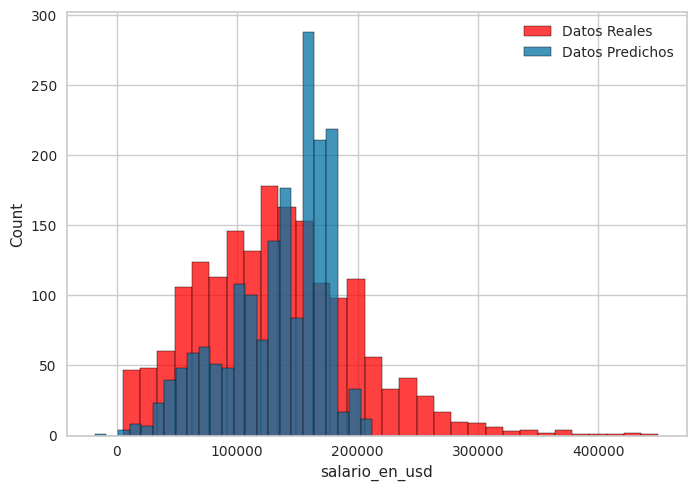

Métricas de Desempeño en Prueba
R2: 0.4178406923232535
RMSE: 0.11672265441983566
MAE: 0.08798560893118625
MAPE: 0.4470641249733541


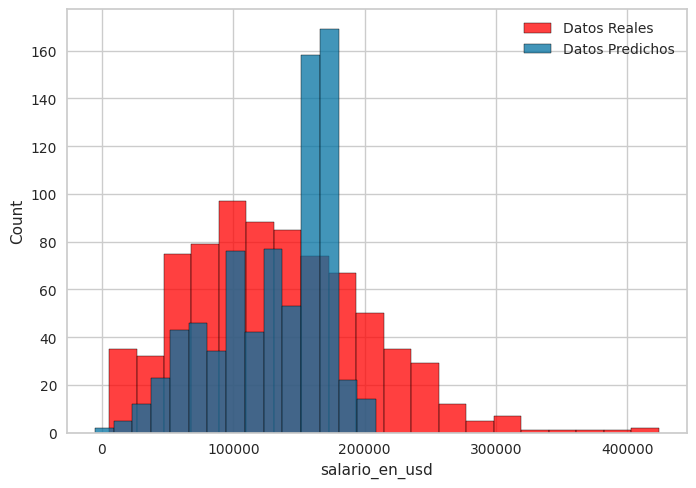

In [29]:
# Restaurar configuración de fuentes (PyCaret puede resetear rcParams)
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']

print('Métricas de Desempeño en Entrenamiento')
print(f'R2: {ridge_r2_train}\nRMSE: {ridge_rmse_train}\nMAE: {ridge_mae_train}\nMAPE: {ridge_mape_train}')
plt.figure()
sns.histplot(data=y_ridge_train_esc, x='salario_en_usd', label='Datos Reales', color='red')
sns.histplot(y_ridge_pred_train_esc, label='Datos Predichos')
plt.legend()
plt.show()

print('Métricas de Desempeño en Prueba')
print(f'R2: {ridge_r2_test}\nRMSE: {ridge_rmse_test}\nMAE: {ridge_mae_test}\nMAPE: {ridge_mape_test}')
plt.figure()
sns.histplot(data=y_ridge_test_esc, x='salario_en_usd', label='Datos Reales', color='red')
sns.histplot(y_ridge_pred_test_esc, label='Datos Predichos')
plt.legend()
plt.show()

### Registro manual del modelo Ridge en MLflow

Además del registro automático que hace PyCaret, se loguea el Ridge construido a mano (con Optuna) de forma **explícita** en MLflow para mostrar el control directo del tracking: parámetros (`alpha`), métricas (R², RMSE, MAE, MAPE en train y test) y el modelo serializado como artefacto.

In [30]:
# Registro EXPLÍCITO del modelo Ridge en MLflow (logging manual) (completado con asistencia de Claude)
# nested=True es necesario porque PyCaret mantiene un run de sesión activo durante el notebook.
import mlflow.sklearn

with mlflow.start_run(run_name='ridge_manual_optuna', nested=True):
    # Parámetros
    mlflow.log_param('modelo', 'Ridge')
    mlflow.log_param('alpha', study.best_params['alpha'])
    mlflow.log_param('n_trials_optuna', 100)
    # Métricas
    mlflow.log_metric('rmse_cv_optuna', study.best_value)
    mlflow.log_metric('r2_train', ridge_r2_train)
    mlflow.log_metric('r2_test', ridge_r2_test)
    mlflow.log_metric('rmse_train', ridge_rmse_train)
    mlflow.log_metric('rmse_test', ridge_rmse_test)
    mlflow.log_metric('mae_train', ridge_mae_train)
    mlflow.log_metric('mae_test', ridge_mae_test)
    mlflow.log_metric('mape_train', ridge_mape_train)
    mlflow.log_metric('mape_test', ridge_mape_test)
    # Modelo como artefacto
    mlflow.sklearn.log_model(ridge_1, artifact_path='modelo_ridge')

print('Run "ridge_manual_optuna" registrado en MLflow (experimento taller3_salarios_ds).')

Run "ridge_manual_optuna" registrado en MLflow (experimento taller3_salarios_ds).


Se revisan las variables que mayor peso tienen en la predicción del salario

In [31]:
importancia_ridge = pd.Series(np.abs(ridge_1.coef_), index=X.columns).sort_values(ascending=False)
print(importancia_ridge)

nivel_experiencia_Otros                     0.102113
nivel_experiencia_EN                        0.090691
titulo_trabajo_Data Analyst                 0.058891
residencia_empleado_US                      0.049920
residencia_empleado_Otros                   0.044051
nivel_experiencia_MI                        0.040870
titulo_trabajo_Machine Learning Engineer    0.038854
ubicacion_empresa_US                        0.031195
nivel_experiencia_SE                        0.029448
tipo_empleo_FT                              0.024852
tipo_empleo_Otros                           0.024852
titulo_trabajo_Otros                        0.022849
tamaño_empresa_S                            0.020879
año_trabajo_2021                            0.019198
ubicacion_empresa_GB                        0.018616
tamaño_empresa_L                            0.014453
año_trabajo_Otros                           0.013725
ubicacion_empresa_Otros                     0.012580
año_trabajo_2023                            0.

# Evaluación

## ¿Cuál es la métrica de desempeño de mayor importancia? ¿Por qué?

Para este problema de **regresión de salarios**, la métrica más importante es el **MAE (Error Absoluto Medio) en dólares**, acompañada del **RMSE** como métrica secundaria.

- **MAE (en USD):** es **directamente interpretable** para el negocio: representa, en promedio, cuántos dólares se equivoca el modelo al estimar un salario. Para RRHH, decir "el modelo se equivoca en promedio ~X USD" es mucho más accionable que un valor abstracto. Además, el MAE es **robusto frente a los outliers** de salario que vimos en el EDA (hay salarios extremos), por lo que no se ve dominado por unos pocos casos atípicos.
- **RMSE (secundaria):** penaliza con más fuerza los errores grandes; es útil para vigilar que el modelo no cometa equivocaciones muy costosas (ofertas muy por encima/por debajo del mercado).
- **R² (complementaria):** indica qué proporción de la variabilidad del salario explica el modelo; sirve para comparar modelos, pero **no** está en unidades de negocio, por lo que no se usa como métrica principal.
- **MAPE:** intuitivo (error %), pero puede inflarse con salarios bajos, por eso se reporta pero no se prioriza.

> En conclusión: se optimiza buscando el **menor MAE en USD** (con RMSE bajo), porque es la métrica que mejor traduce el desempeño del modelo a una decisión salarial concreta.

## Definición del mejor modelo

Se selecciona el mejor modelo a partir de la tabla de los 5 modelos tuneados con Optuna (`tabla_tuneo`). Para alinear la selección con el negocio, se ordena por **MAE** (menor error en la escala del target); también se muestran R² y RMSE.

In [32]:
# Selección del mejor modelo según MAE (menor error) (completado con asistencia de Claude)
tabla_ordenada = tabla_tuneo.sort_values('MAE', ascending=True)
print('Ranking de modelos tuneados (ordenado por MAE):')
print(tabla_ordenada[['MAE', 'RMSE', 'R2']])

mejor_nombre = tabla_ordenada.index[0]
mejor_modelo = modelos_tuneados[mejor_nombre]
print(f'\n>>> El MEJOR modelo es: "{mejor_nombre}"')
print(tabla_ordenada.loc[mejor_nombre])

Ranking de modelos tuneados (ordenado por MAE):
          MAE    RMSE      R2
ridge  0.0902  0.1197  0.3807
gbr    0.0902  0.1197  0.3806
rf     0.0904  0.1193  0.3854
dt     0.0914  0.1213  0.3647
lasso  0.1210  0.1533 -0.0094

>>> El MEJOR modelo es: "ridge"
MAE      0.0902
MSE      0.0144
RMSE     0.1197
R2       0.3807
RMSLE    0.0886
MAPE     0.8613
Name: ridge, dtype: float64


## ¿Cuáles son las variables que más afectan al modelo?

Se obtienen las variables más influyentes del mejor modelo. Si es un modelo de árbol/ensamble se usa `feature_importances_`; si es lineal se usan los coeficientes (`coef_`). Esto responde qué características del perfil pesan más al estimar el salario.

Importancia de variables del modelo "ridge" (via coeficientes (|coef_|)):

nivel_experiencia_Otros                     0.104057
nivel_experiencia_EN                        0.088380
residencia_empleado_US                      0.065078
titulo_trabajo_Data Analyst                 0.060963
residencia_empleado_Otros                   0.054586
nivel_experiencia_MI                        0.040885
titulo_trabajo_Otros                        0.032619
titulo_trabajo_Machine Learning Engineer    0.030746
nivel_experiencia_SE                        0.025200
ubicacion_empresa_US                        0.023859
ubicacion_empresa_GB                        0.021731
tamaño_empresa_S                            0.020498
tipo_empleo_Otros                           0.018269
tipo_empleo_FT                              0.018269
tamaño_empresa_L                            0.016135
dtype: float32


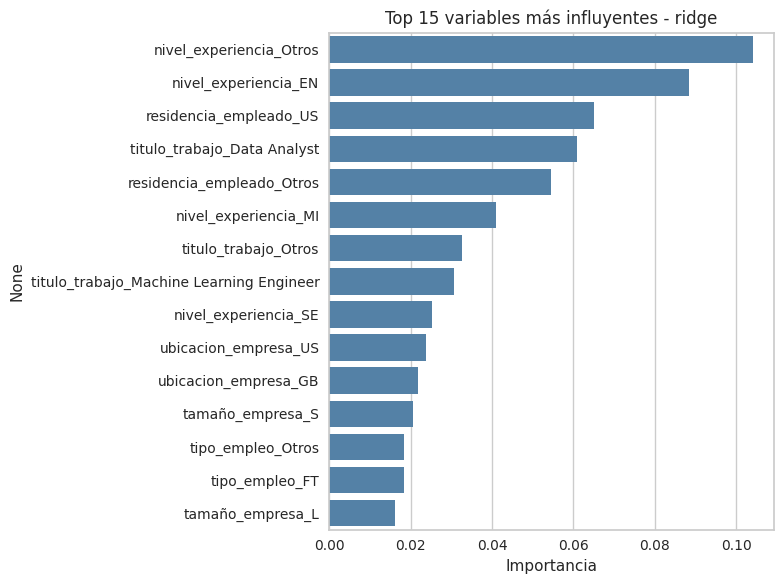

In [33]:
# Variables más influyentes del mejor modelo (completado con asistencia de Claude)
# get_config('X_train') devuelve las features transformadas por PyCaret con sus nombres
X_train_py = get_config('X_train')

if hasattr(mejor_modelo, 'feature_importances_'):
    importancias = pd.Series(mejor_modelo.feature_importances_, index=X_train_py.columns)
    tipo_imp = 'feature_importances_'
else:
    importancias = pd.Series(np.abs(mejor_modelo.coef_).ravel(), index=X_train_py.columns)
    tipo_imp = 'coeficientes (|coef_|)'

importancias = importancias.sort_values(ascending=False)
print(f'Importancia de variables del modelo "{mejor_nombre}" (via {tipo_imp}):\n')
print(importancias.head(15))

# Restaurar fuentes por si PyCaret reseteó rcParams
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']

plt.figure(figsize=(8, 6))
sns.barplot(x=importancias.head(15).values, y=importancias.head(15).index, color='steelblue')
plt.title(f'Top 15 variables más influyentes - {mejor_nombre}')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

## ¿Valdría la pena usar el mejor modelo en el día a día de una empresa/institución?

**Sí, como herramienta de apoyo, no como decisión automática.** Justificación:

- **A favor:** el modelo da una **estimación rápida y consistente** de la banda salarial según el perfil, útil para que RRHH construya ofertas competitivas y para que los candidatos tengan un *benchmark*. Encapsulado en un pipeline (ver despliegue), se consulta vía API sin conocimiento técnico, lo que lo hace operativo en el día a día.
- **Limitaciones a tener en cuenta:**
  - **Sesgo del dataset:** los datos están dominados por EE. UU. y por ciertos roles/años; la estimación es menos confiable para países o cargos poco representados (de ahí la agrupación en `Otros`).
  - **Variabilidad alta del salario:** el salario depende de factores no presentes en los datos (habilidades específicas, negociación, sector), por lo que siempre habrá un error residual (ver MAE/RMSE).
  - **Mantenimiento:** el mercado salarial cambia; el modelo debe **reentrenarse periódicamente** con datos recientes para no quedar desactualizado.
- **Conclusión:** vale la pena usarlo como **referencia/segunda opinión** dentro del proceso de compensación, acompañado de criterio humano y de un monitoreo continuo del error en producción.

> *(Respuestas de evaluación completadas con asistencia de Claude.)*

# Despliegue

Para producción se construye un **pipeline único** que recibe los **datos crudos del perfil** (sin transformar) y devuelve directamente el **salario estimado en USD**. 

**¿Por qué el pipeline de producción es distinto al de exploración?**
- En la exploración escalamos el target con MinMax y agrupamos categorías a mano (pasos separados). Eso es útil para comparar modelos, pero **no sirve para producción**, donde el usuario solo debe enviar datos crudos.
- El pipeline de producción encapsula **todo** el preprocesamiento dentro de sí mismo:
  - `OneHotEncoder(min_frequency=0.05, handle_unknown='infrequent_if_exist')` agrupa las categorías raras (<5%) **automáticamente** y maneja categorías nunca vistas, sin necesidad de código personalizado (esto hace que el `.pkl` se cargue solo con scikit-learn, sin clases propias).
  - Predice `salario_en_usd` **en dólares** (sin escalar el target), para que la respuesta sea directamente interpretable.
- Se reentrena el **mejor tipo de modelo** (el ganador de la búsqueda con Optuna) sobre las variables crudas usando `clone()` para conservar sus hiperparámetros.

In [34]:
# Construcción del pipeline de producción raw -> USD (completado con asistencia de Claude)
from sklearn.base import clone

# 1) Reconstruimos los datos CRUDOS (renombrados a español, sin transformaciones)
datos_crudos = data_csv.copy().rename(columns=renombrar).drop_duplicates()

# Variables de entrada del perfil (lo único que se le pedirá al usuario)
columnas_entrada = ['año_trabajo', 'nivel_experiencia', 'tipo_empleo', 'titulo_trabajo',
                    'residencia_empleado', 'ratio_remoto', 'ubicacion_empresa', 'tamaño_empresa']

# año_trabajo y ratio_remoto se tratan como categóricas (igual que en la exploración)
X_prod = datos_crudos[columnas_entrada].astype(str)
y_prod = datos_crudos['salario_en_usd']   # target en USD, SIN escalar

# 2) Preprocesador autocontenido: OHE con agrupación de raras + manejo de desconocidas
preprocesador_prod = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=0.05),
         columnas_entrada)
    ],
    remainder='drop'
)

# 3) Pipeline = preprocesamiento + mejor modelo (clonado para conservar hiperparámetros)
pipeline_final = Pipeline(steps=[
    ('preprocesador', preprocesador_prod),
    ('modelo', clone(mejor_modelo))
])

# 4) Evaluación honesta en un holdout (métricas en USD)
X_tr, X_te, y_tr, y_te = train_test_split(X_prod, y_prod, train_size=0.7, random_state=15)
pipeline_final.fit(X_tr, y_tr)
pred_te = pipeline_final.predict(X_te)
print('Desempeño del pipeline de producción (holdout, en USD):')
print(f'MAE : {mean_absolute_error(y_te, pred_te):,.0f} USD')
print(f'RMSE: {root_mean_squared_error(y_te, pred_te):,.0f} USD')
print(f'R2  : {r2_score(y_te, pred_te):.3f}')

# 5) Reentrenamiento final con TODOS los datos para el modelo que va a producción
pipeline_final.fit(X_prod, y_prod)
print('\nPipeline final reentrenado con todos los datos y listo para desplegar.')

Desempeño del pipeline de producción (holdout, en USD):
MAE : 39,154 USD
RMSE: 51,934 USD
R2  : 0.418



Pipeline final reentrenado con todos los datos y listo para desplegar.


In [35]:
# Guardado del pipeline final + registro en MLflow (completado con asistencia de Claude)
import joblib

# Se serializa el pipeline completo (preprocesamiento + modelo) para usarlo en FastAPI
joblib.dump(pipeline_final, 'modelo_salarios.pkl')
print('Pipeline guardado en: modelo_salarios.pkl')

# nested=True porque PyCaret mantiene un run de sesión activo durante el notebook.
with mlflow.start_run(run_name='pipeline_produccion', nested=True):
    mlflow.log_param('mejor_modelo', mejor_nombre)
    mlflow.log_param('columnas_entrada', ', '.join(columnas_entrada))
    mlflow.log_metric('mae_holdout_usd', mean_absolute_error(y_te, pred_te))
    mlflow.log_metric('rmse_holdout_usd', root_mean_squared_error(y_te, pred_te))
    mlflow.log_metric('r2_holdout', r2_score(y_te, pred_te))
    mlflow.sklearn.log_model(pipeline_final, artifact_path='pipeline_salarios')
print('Pipeline de producción registrado en MLflow.')

Pipeline guardado en: modelo_salarios.pkl


Pipeline de producción registrado en MLflow.


In [36]:
# Prueba del pipeline: se carga el .pkl y se predice con un perfil CRUDO de ejemplo (completado con asistencia de Claude)
pipeline_cargado = joblib.load('modelo_salarios.pkl')

# El usuario solo ingresa datos crudos, sin ninguna transformación
ejemplo = pd.DataFrame([{
    'año_trabajo': '2023',
    'nivel_experiencia': 'SE',
    'tipo_empleo': 'FT',
    'titulo_trabajo': 'Data Scientist',
    'residencia_empleado': 'US',
    'ratio_remoto': '100',
    'ubicacion_empresa': 'US',
    'tamaño_empresa': 'M'
}])

prediccion = pipeline_cargado.predict(ejemplo)
print(f'Salario estimado para el perfil de ejemplo: {prediccion[0]:,.0f} USD')

Salario estimado para el perfil de ejemplo: 167,734 USD


## Endpoint con FastAPI, despliegue en EC2 y daemon

El pipeline (`modelo_salarios.pkl`) se expone con **FastAPI** en el archivo [`app.py`](app.py): tiene un endpoint `POST /predict` que recibe el perfil crudo en JSON y devuelve el salario estimado en USD, más un `GET /` de *health-check*.

**Prueba local:**
```bash
uvicorn app:app --host 0.0.0.0 --port 8000
curl -X POST http://localhost:8000/predict -H "Content-Type: application/json" \
  -d '{"año_trabajo":"2023","nivel_experiencia":"SE","tipo_empleo":"FT","titulo_trabajo":"Data Scientist","residencia_empleado":"US","ratio_remoto":"100","ubicacion_empresa":"US","tamaño_empresa":"M"}'
```

**Despliegue en EC2 + daemon (systemd):** los pasos completos (lanzar la instancia, abrir el puerto 8000 en el *security group*, instalar dependencias, copiar el `.pkl`, instalar el servicio `taller3-fastapi.service` con `systemctl enable --now` para que el API quede **siempre arriba** aunque se cierre la terminal, y el `curl` remoto de verificación) están documentados paso a paso en el [`README.md`](README.md) del repositorio.

> *(Sección de despliegue completada con asistencia de Claude.)*

#Prueba completa desde local a servidor con daemon

 curl -X POST http://18.226.65.132:7000/predict   -H "Content-Type: application/json"   -d '{"año_trabajo":"2023","nivel_experiencia":"SE","tipo_empleo":"FT","titulo_trabajo":"Data Scientist","residencia_empleado":"US","ratio_remoto":"100","ubicacion_empresa":"US","tamaño_empresa":"M"}'

![Curl desde local a endpoint](Curl%20desde%20local%20a%20endpoint.png)

Posdata: Apagaré el servidor en 10 días por el momento seguirá arriba